# Netflix Customer Churn Analysis

---
---

### Identifying behavioural patterns and revenue impact of customer churn

**Author:** Nilesh Chaudhary  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Dataset:** Netflix User Behaviour Dataset — 50,000 users, 20 features  

---

## Business Problem
Netflix and other streaming platforms lose significant monthly revenue when users cancel 
or stop engaging. <br>This analysis identifies **who churns, why they churn, and what 
it costs**, using behavioural data to segment users into actionable personas.

---

## Objectives
- Identify the strongest predictors of churn
- Segment users by engagement and activity levels
- Quantify revenue at risk from churned users
- Define 3 customer personas for targeted retention strategies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('netflix_churn_dataset.csv')
print(df.shape)

(50000, 20)


In [3]:
df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,UK,53,Premium,19.50,Debit Card,Mobile,4,Romance,276,10,5,88,5.0,72,72,18,No
1,U100001,46,Male,Canada,20,Premium,19.47,Credit Card,Mobile,2,Horror,137,6,0,37,2.0,64,5,24,Yes
2,U100002,32,Male,Brazil,42,Basic,10.16,PayPal,Smart TV,4,Horror,338,8,7,22,3.0,51,93,46,Yes
3,U100003,60,Male,USA,19,Standard,16.35,UPI,Laptop,4,Sci-Fi,253,9,9,53,3.4,39,30,9,No
4,U100004,25,Male,India,11,Standard,14.30,Credit Card,Tablet,1,Comedy,153,3,12,96,4.1,55,81,9,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    50000 non-null  object 
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   country                    50000 non-null  object 
 4   account_age_months         50000 non-null  int64  
 5   subscription_type          50000 non-null  object 
 6   monthly_fee                50000 non-null  float64
 7   payment_method             50000 non-null  object 
 8   primary_device             50000 non-null  object 
 9   devices_used               50000 non-null  int64  
 10  favorite_genre             50000 non-null  object 
 11  avg_watch_time_minutes     50000 non-null  int64  
 12  watch_sessions_per_week    50000 non-null  int64  
 13  binge_watch_sessions       50000 non-null  int

In [5]:
df.describe()

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,40.979240,30.152360,14.512406,2.505940,360.204800,10.009940,6.985040,59.617120,2.996854,39.93890,49.458620,29.657120
std,13.528733,17.038394,4.008059,1.120424,191.465782,5.482875,4.313554,23.119449,1.157432,22.85662,25.964726,17.279616
min,18.000000,1.000000,8.000000,1.000000,30.000000,1.000000,0.000000,20.000000,1.000000,1.00000,5.000000,0.000000
25%,29.000000,15.000000,10.880000,2.000000,191.000000,5.000000,3.000000,40.000000,2.000000,20.00000,27.000000,15.000000
50%,41.000000,30.000000,14.510000,3.000000,364.000000,10.000000,7.000000,60.000000,3.000000,40.00000,50.000000,30.000000
75%,53.000000,45.000000,18.020000,4.000000,570.000000,15.000000,11.000000,80.000000,4.000000,60.00000,72.000000,45.000000
max,64.000000,59.000000,22.000000,4.000000,600.000000,19.000000,14.000000,99.000000,5.000000,79.00000,94.000000,59.000000


In [6]:
df['churned'] = df['churned'].map({'Yes':1, 'No':0})

In [7]:
df['churned'].value_counts()

churned
0    34051
1    15949
Name: count, dtype: int64

# 1. Churn rate by Subscription Type

In [8]:
df.groupby('subscription_type')['churned'].mean().sort_values(ascending=False).round(3)

subscription_type
Premium     0.373
Standard    0.325
Basic       0.273
Name: churned, dtype: float64

# 2. Churn rate by Average Watch Time

In [9]:
df.groupby('churned')['avg_watch_time_minutes'].mean().round(2)

churned
0    403.26
1    268.28
Name: avg_watch_time_minutes, dtype: float64

# 3. Churn rate by Primary Device Type

In [10]:
df.groupby('primary_device')['churned'].mean().sort_values(ascending=False).round(3)

primary_device
Laptop      0.324
Smart TV    0.321
Mobile      0.316
Tablet      0.315
Name: churned, dtype: float64

# 4. Churn rate by Days Since Last Login

In [11]:
df.groupby('churned')['days_since_last_login'].mean().round(2)

churned
0    23.80
1    42.16
Name: days_since_last_login, dtype: float64

# 5. Churn rate by Account Age in Months

In [12]:
df.groupby('churned')['account_age_months'].mean().round(2)

churned
0    30.37
1    29.69
Name: account_age_months, dtype: float64

# 6. Churn rate by Engagement

In [13]:
df.groupby('churned')[['completion_rate','content_interactions','recommendation_click_rate']].mean().round(2)

,completion_rate,content_interactions,recommendation_click_rate
churned,,,
0,63.04,39.91,52.01
1,52.31,40.00,44.02


# 7. Churn rate by Engagement Level

In [14]:
df['engagement_level'] = pd.qcut(df['avg_watch_time_minutes'], 3, labels=['Low','Medium','High'])

df.groupby('engagement_level')['churned'].mean()

engagement_level
Low       0.511269
Medium    0.285354
High      0.159199
Name: churned, dtype: float64

# 8. Churn rate by Activity Level

In [15]:
df['activity_level'] = pd.qcut(df['days_since_last_login'], 3, labels=['Active','Moderate','Inactive'])

df.groupby('activity_level')['churned'].mean()

activity_level
Active      0.072678
Moderate    0.289161
Inactive    0.616251
Name: churned, dtype: float64

# 9. For Combined Feature Analysis (Subscription + Engagement)

In [16]:
df.groupby(['subscription_type','engagement_level'])['churned'].mean()

subscription_type  engagement_level
Basic              Low                 0.460062
                   Medium              0.236806
                   High                0.121149
Premium            Low                 0.569136
                   Medium              0.341236
                   High                0.204578
Standard           Low                 0.519309
                   Medium              0.292885
                   High                0.163905
Name: churned, dtype: float64

# 10. For Behavioral Segmentation (Binge Users)

In [17]:
df['binge_user'] = df['binge_watch_sessions'] > df['binge_watch_sessions'].median()

df.groupby('binge_user')['churned'].mean()

binge_user
False    0.402090
True     0.223795
Name: churned, dtype: float64

# 11. High Risk Users

In [18]:
df['high_risk'] = (
    (df['avg_watch_time_minutes'] < df['avg_watch_time_minutes'].median()) &
    (df['days_since_last_login'] > df['days_since_last_login'].median())
)

df.groupby('high_risk')['churned'].mean()

high_risk
False    0.191906
True     0.712915
Name: churned, dtype: float64

# 12. New vs Old Customers Churn rate

In [19]:
df['customer_tenure']=pd.cut(df['account_age_months'], bins=[0,6,12,24,60], labels=['New (0-6m)','Early (6-12m)','Established (1-2yr)','Loyal (2yr+)'])
df.groupby('customer_tenure')['churned'].mean().sort_values(ascending=False).round(3)

customer_tenure
New (0-6m)             0.358
Early (6-12m)          0.320
Established (1-2yr)    0.317
Loyal (2yr+)           0.313
Name: churned, dtype: float64

# 13. Revenue at risk (how much monthly fee is at risk from churned users)

In [20]:
total_revenue = df['monthly_fee'].sum()
churned_revenue = df[df['churned']==1]['monthly_fee'].sum()
print(f"Total monthly revenue: ${total_revenue:,.2f}")
print(f"Revenue lost to churn: ${churned_revenue:,.2f}")
print(f"Churn revenue %: {(churned_revenue/total_revenue*100):.1f}%")

Total monthly revenue: $725,620.30
Revenue lost to churn: $239,742.74
Churn revenue %: 33.0%


# 14. What % of users are high-risk AND on Premium

In [21]:
premium_high_risk = df[(df['subscription_type']=='Premium') & (df['high_risk']==True)]
print(f"High-risk Premium users: {len(premium_high_risk):,}")
print(f"Their churn rate: {premium_high_risk['churned'].mean():.1%}")
print(f"Monthly revenue at risk: ${premium_high_risk[premium_high_risk['churned']==1]['monthly_fee'].sum():,.2f}")

High-risk Premium users: 3,119
Their churn rate: 77.2%
Monthly revenue at risk: $48,173.17


# 15. New customers who are also inactive

In [22]:
new_inactive = df[(df['customer_tenure']=='New (0-6m)') & (df['activity_level']=='Inactive')]
print(f"New + Inactive users: {len(new_inactive):,}")
print(f"Churn rate: {new_inactive['churned'].mean():.1%}")

New + Inactive users: 1,627
Churn rate: 67.2%


# 16. Define your 3 customer personas

In [23]:
# Persona 1: Loyal Watchers
loyal = df[(df['binge_user']==True) & (df['activity_level']=='Active')]
# Persona 2: At-Risk Passives  
at_risk = df[(df['high_risk']==True) & (df['customer_tenure']!='Loyal (2yr+)')]
# Persona 3: New Strugglers
new_struggle = df[(df['customer_tenure']=='New (0-6m)') & (df['engagement_level']=='Low')]

print("=== PERSONA 1: Loyal Watchers ===")
print(f"Count: {len(loyal):,} | Churn rate: {loyal['churned'].mean():.1%}")

print("\n=== PERSONA 2: At-Risk Passives ===")
print(f"Count: {len(at_risk):,} | Churn rate: {at_risk['churned'].mean():.1%}")
print(f"Revenue at risk: ${at_risk[at_risk['churned']==1]['monthly_fee'].sum():,.2f}")

print("\n=== PERSONA 3: New Strugglers ===")
print(f"Count: {len(new_struggle):,} | Churn rate: {new_struggle['churned'].mean():.1%}")

=== PERSONA 1: Loyal Watchers ===
Count: 8,141 | Churn rate: 2.7%

=== PERSONA 2: At-Risk Passives ===
Count: 4,884 | Churn rate: 72.6%
Revenue at risk: $52,259.67

=== PERSONA 3: New Strugglers ===
Count: 1,641 | Churn rate: 57.2%


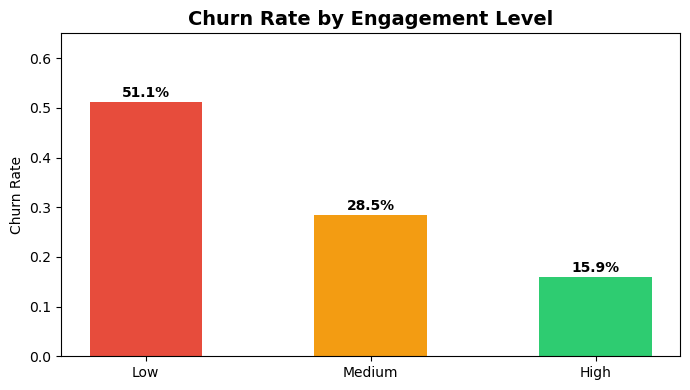

Insight: Low-engagement users churn at 51.1% vs 15.9% for high-engagement users.
Watch time directly predicts whether a user stays or leaves.


In [24]:
engagement_churn = df.groupby('engagement_level')['churned'].mean().round(3)

plt.figure(figsize=(7, 4))
plt.bar(engagement_churn.index, engagement_churn.values, color=['#e74c3c','#f39c12','#2ecc71'], width=0.5)
plt.title('Churn Rate by Engagement Level', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate')
plt.ylim(0, 0.65)
for i, v in enumerate(engagement_churn.values):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_engagement_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("\033[1mInsight: Low-engagement users churn at 51.1% vs 15.9% for high-engagement users.\033[0m")
print("\033[1mWatch time directly predicts whether a user stays or leaves.\033[0m")

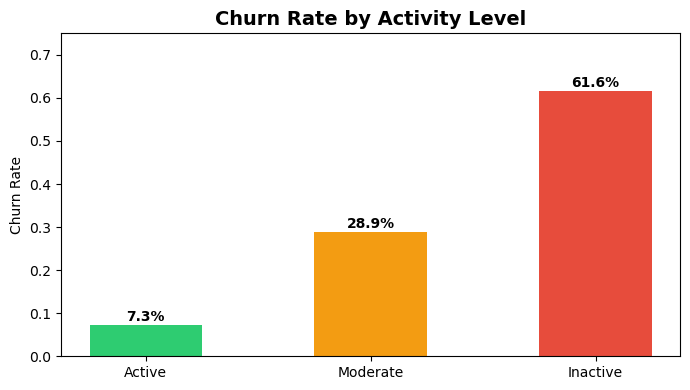

Insight: Inactive users churn at 61.6% compared to just 7.3% for active users.
Days since last login is the single strongest churn predictor in this dataset.


In [25]:
activity_churn = df.groupby('activity_level')['churned'].mean().round(3)

plt.figure(figsize=(7, 4))
bars = plt.bar(activity_churn.index, activity_churn.values, color=['#2ecc71','#f39c12','#e74c3c'], width=0.5)
plt.title('Churn Rate by Activity Level', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate')
plt.ylim(0, 0.75)
for i, v in enumerate(activity_churn.values):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_activity_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("\033[1mInsight: Inactive users churn at 61.6% compared to just 7.3% for active users.\033[0m")
print("\033[1mDays since last login is the single strongest churn predictor in this dataset.\033[0m")

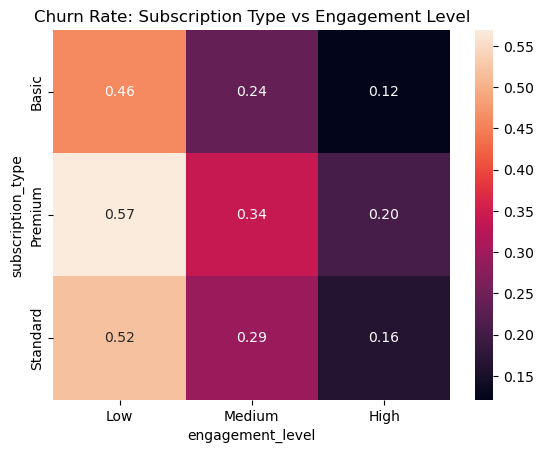

Insight: Premium + Low Engagement is the most dangerous combination at 56.9% churn.
High-cost users who don't watch feel the subscription isn't worth it.


In [26]:
pivot = df.pivot_table(values='churned',
                       index='subscription_type',
                       columns='engagement_level')

plt.figure()
sns.heatmap(pivot, annot=True, fmt=".2f")
plt.title('Churn Rate: Subscription Type vs Engagement Level')
plt.show()

print("\033[1mInsight: Premium + Low Engagement is the most dangerous combination at 56.9% churn.\033[0m")
print("\033[1mHigh-cost users who don't watch feel the subscription isn't worth it.\033[0m")

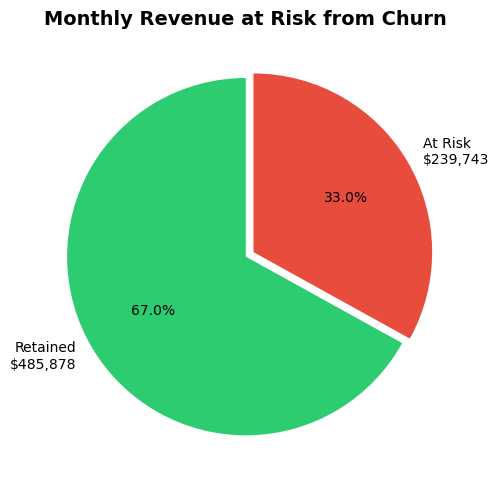

Insight: $239,743 in monthly revenue is at risk, that is $2.87M annually if unaddressed.


In [27]:
plt.figure(figsize=(6, 5))
plt.pie(
    [total_revenue - churned_revenue, churned_revenue],
    labels=[f'Retained\n${total_revenue - churned_revenue:,.0f}',
            f'At Risk\n${churned_revenue:,.0f}'],
    colors=['#2ecc71','#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05)
)
plt.title('Monthly Revenue at Risk from Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print("\033[1mInsight: $239,743 in monthly revenue is at risk, that is $2.87M annually if unaddressed.\033[0m")

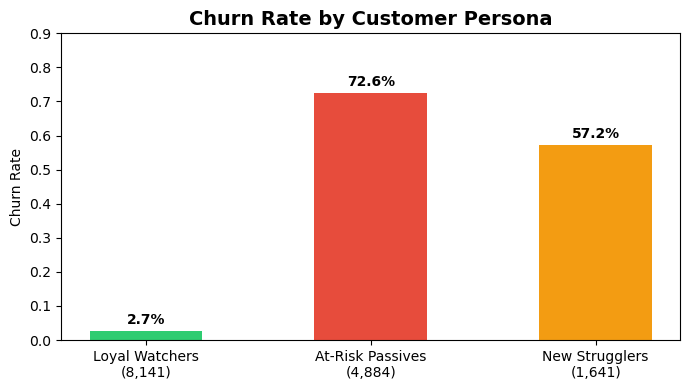

Insight: At-Risk Passives churn at 72.6% — nearly 3 in 4 will leave without intervention.
Loyal Watchers at 2.7% churn are the core stable base to protect.


In [28]:
personas = ['Loyal Watchers\n(8,141)', 'At-Risk Passives\n(4,884)', 'New Strugglers\n(1,641)']
churn_rates = [0.027, 0.726, 0.572]

plt.figure(figsize=(7, 4))
plt.bar(personas, churn_rates, color=['#2ecc71','#e74c3c','#f39c12'], width=0.5)
plt.title('Churn Rate by Customer Persona', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate')
plt.ylim(0, 0.9)
for i, v in enumerate(churn_rates):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_personas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\033[1mInsight: At-Risk Passives churn at 72.6% — nearly 3 in 4 will leave without intervention.\033[0m")
print("\033[1mLoyal Watchers at 2.7% churn are the core stable base to protect.\033[0m")

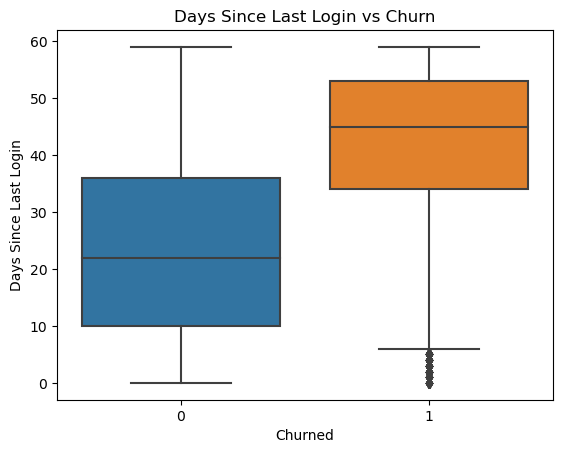

Insight: Churned users logged in 42 days ago on average vs 24 days for retained users.
A gap of 30+ days since last login should trigger a re-engagement alert.


In [29]:
plt.figure()
sns.boxplot(x='churned', y='days_since_last_login', data=df)
plt.title('Days Since Last Login vs Churn')
plt.xlabel('Churned')
plt.ylabel('Days Since Last Login')
plt.show()

print("\033[1mInsight: Churned users logged in 42 days ago on average vs 24 days for retained users.\033[0m")
print("\033[1mA gap of 30+ days since last login should trigger a re-engagement alert.\033[0m")

---
# **Key Insights**
1. Churn is primarily driven by behavioral factors (engagement & activity)
2. Inactive users are the highest-risk segment
3. Early-stage users churn more, indicating onboarding gaps
4. Premium users show higher churn, suggesting value mismatch
5. Demographics (age, country) have minimal impact
6. Churn results in significant revenue loss (~33%)
---

# **Conclusion**

This analysis demonstrates that customer churn is primarily driven by user engagement and activity patterns
<br>rather than demographic factors. By identifying high-risk segments and understanding behavioral pattern,
<br>the platform can implement targeted retention strategies to significantly reduce churn and improve revenue performance.

---

# **Strategic Business Recommendations** 
1. Improve Onboarding Experience
Focus on first 30 days
Guide users to relevant content
2. Implement Re-Engagement Campaigns
Target inactive users
Use push notifications and email reminders
3. Enhance Recommendation System
Personalized suggestions
Increase content discovery
4. Redesign Premium Offering
Add exclusive benefits
Improve perceived value
5. Target High-Risk Users
Focus on users with low engagement + inactivity
Offer incentives / discounts

---
---

---
---
## Part - 2  Machine Learning: Churn Prediction Model

**Objective:** The goal of this model is to predict whether a customer will churn, and to identify the most important factors driving churn. <br>This helps in proactively identifying high-risk users and enabling targeted retention strategies.

**Algorithm:** Random Forest Classifier

**Train/Test Split:** 80/20 stratified split (40,000 train / 10,000 test)

---

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


In [31]:
# Select only original columns, drop derived ones we created during EDA
ml_df = df[['age', 'gender', 'country', 'account_age_months', 'subscription_type',
            'monthly_fee', 'payment_method', 'primary_device', 'devices_used',
            'favorite_genre', 'avg_watch_time_minutes', 'watch_sessions_per_week',
            'binge_watch_sessions', 'completion_rate', 'rating_given',
            'content_interactions', 'recommendation_click_rate',
            'days_since_last_login', 'churned']].copy()

print("Shape:", ml_df.shape)
print("Columns:", ml_df.columns.tolist())

Shape: (50000, 19)
Columns: ['age', 'gender', 'country', 'account_age_months', 'subscription_type', 'monthly_fee', 'payment_method', 'primary_device', 'devices_used', 'favorite_genre', 'avg_watch_time_minutes', 'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate', 'rating_given', 'content_interactions', 'recommendation_click_rate', 'days_since_last_login', 'churned']


In [32]:
le = LabelEncoder()
cat_cols = ['gender', 'country', 'subscription_type', 'payment_method',
            'primary_device', 'favorite_genre']

for col in cat_cols:
    ml_df[col] = le.fit_transform(ml_df[col])

print("Encoding done.")
ml_df.head(5)

Encoding done.


,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,56,1,8,53,1,19.50,1,1,4,5,276,10,5,88,5.0,72,72,18,0
1,46,1,2,20,1,19.47,0,1,2,4,137,6,0,37,2.0,64,5,24,1
2,32,1,1,42,0,10.16,2,2,4,4,338,8,7,22,3.0,51,93,46,1
3,60,1,9,19,2,16.35,3,0,4,6,253,9,9,53,3.4,39,30,9,0
4,25,1,5,11,2,14.30,0,3,1,1,153,3,12,96,4.1,55,81,9,0


In [33]:
X = ml_df.drop('churned', axis=1)
y = ml_df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test : {y_test.mean():.2%}")

Training set : (40000, 18)
Test set     : (10000, 18)
Churn rate in train: 31.90%
Churn rate in test : 31.90%


In [34]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [35]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

 Not Churned       0.88      0.94      0.91      6810
     Churned       0.85      0.73      0.78      3190

    accuracy                           0.87     10000
   macro avg       0.86      0.83      0.85     10000
weighted avg       0.87      0.87      0.87     10000

ROC-AUC Score: 0.9434


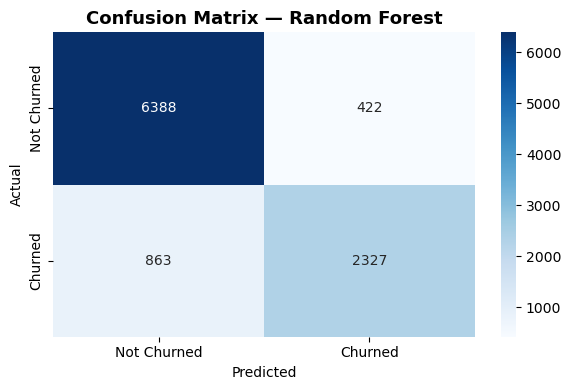

In [36]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

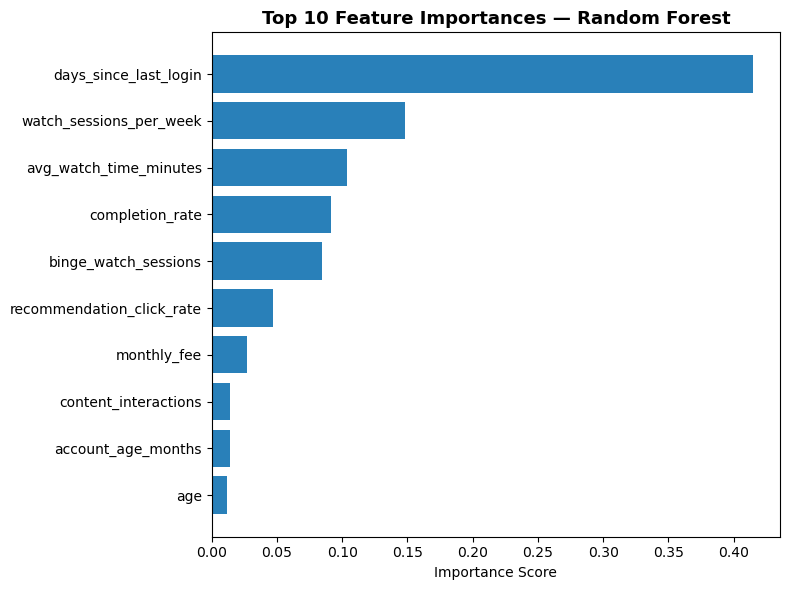

                  feature  importance
    days_since_last_login    0.414747
  watch_sessions_per_week    0.147745
   avg_watch_time_minutes    0.103871
          completion_rate    0.091093
     binge_watch_sessions    0.084329
recommendation_click_rate    0.046641
              monthly_fee    0.027027
     content_interactions    0.013846
       account_age_months    0.013828
                      age    0.011906


In [37]:
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(feat_imp['feature'][:10][::-1],
         feat_imp['importance'][:10][::-1],
         color='#2980b9')
plt.title('Top 10 Feature Importances — Random Forest',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(feat_imp.head(10).to_string(index=False))

In [38]:
# Add churn probability to dataframe
X_all = ml_df.drop('churned', axis=1)
ml_df['churn_probability'] = rf_model.predict_proba(X_all)[:, 1]

# Top 10 highest risk users
top_risk = ml_df.nlargest(10, 'churn_probability')[
    ['churn_probability', 'days_since_last_login',
     'watch_sessions_per_week', 'avg_watch_time_minutes',
     'subscription_type', 'monthly_fee']
]

print("=== TOP 10 HIGHEST CHURN RISK USERS ===")
print(top_risk.round(3).to_string(index=False))

# Risk distribution
print("\n=== CHURN RISK DISTRIBUTION ===")
bins = [0, 0.3, 0.6, 0.8, 1.0]
labels = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
ml_df['risk_segment'] = pd.cut(ml_df['churn_probability'], bins=bins, labels=labels)
print(ml_df['risk_segment'].value_counts().sort_index())

=== TOP 10 HIGHEST CHURN RISK USERS ===
 churn_probability  days_since_last_login  watch_sessions_per_week  avg_watch_time_minutes  subscription_type  monthly_fee
             0.992                     56                        1                      45                  2        16.44
             0.991                     55                        1                      30                  2        16.13
             0.991                     55                        1                      46                  2        16.92
             0.990                     57                        1                      32                  2        15.01
             0.990                     57                        1                      57                  1        19.07
             0.990                     55                        2                      85                  2        15.61
             0.990                     51                        1                      49         

In [39]:
# Export final dataset with risk segments for Power BI
export_df = df[['age', 'gender', 'country', 'account_age_months',
                'subscription_type', 'monthly_fee', 'primary_device',
                'avg_watch_time_minutes', 'watch_sessions_per_week',
                'binge_watch_sessions', 'completion_rate',
                'days_since_last_login', 'churned']].copy()

export_df['churn_probability'] = ml_df['churn_probability'].values
export_df['risk_segment'] = ml_df['risk_segment'].values

export_df.to_csv('netflix_churn_powerbi.csv', index=False)
print("Exported:", export_df.shape)

Exported: (50000, 15)


---
### Model Performance
| Metric | Score |
|---|---|
| Accuracy | 87% |
| ROC-AUC | 0.94 |
| Precision (Churned) | 85% |
| Recall (Churned) | 73% |

---

---
### Key Finding
`days_since_last_login` alone explains **42% of the model's decisions**.
<br>Top 5 predictors are all behavioural — age, gender and country have near-zero importance.
<br>Churn is driven by **what users do, not who they are.**

---

---
### Risk Segments Identified
| Segment | Users | Recommended Action |
|---|---|---|
| Critical Risk | 5,893 | Immediate outreach |
| High Risk | 5,528 | Re-engagement campaign |
| Medium Risk | 8,781 | Monitor monthly |
| Low Risk | 29,798 | No action needed |

---

---
## Project Summary

| Phase | Tool | Key Output |
|---|---|---|
| EDA | Python | 16 analyses, 6 charts, 3 personas |
| SQL | MySQL | 10 queries, $239K revenue at risk identified |
| ML Model | Scikit-learn | 87% accuracy, 0.94 ROC-AUC |
| Dashboard | Power BI | 3-page interactive dashboard |

**Total users analysed:** 50,000  
**Churn rate:** 31.9%  
**Revenue at risk:** $239,743/month ($2.87M/year)  
**High-risk users flagged:** 11,421  